<a href="https://colab.research.google.com/github/Aqillaaprly/PVCK_2025/blob/main/Week6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


2.	Import the following libraries that will be used during the following week 6 practicum trial.

In [2]:
import cv2 as cv
from google.colab.patches import cv2_imshow
from skimage import io
import matplotlib.pyplot as plt
import numpy as np
import math
import os
import glob

3.	Make an image histogram like the following histogram output based on the flowchart below :(Use image lena.jpg)

Image loaded successfully.


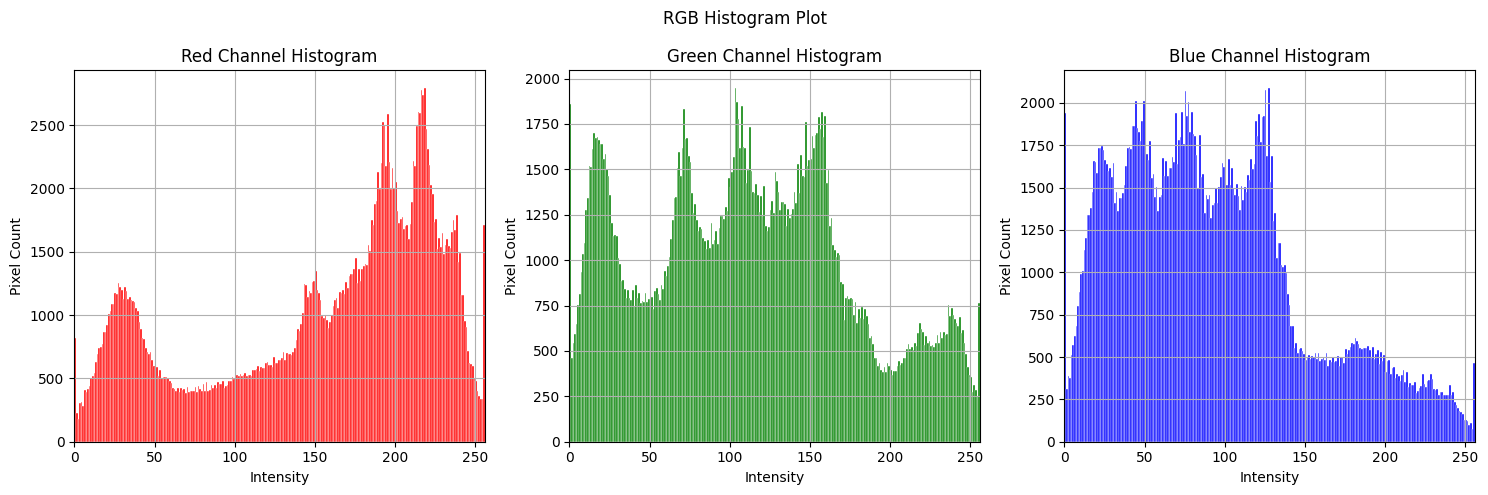

In [3]:
# Step 1: Load the image
image_path = "/content/drive/MyDrive/Images/lena.jpg"
image = cv.imread(image_path)

# Step 2: Check if the image was loaded successfully
if image is None:
    print("Image not found.")
else:
    print("Image loaded successfully.")

    # Step 3: Convert BGR (OpenCV default) to RGB for proper display
    image_rgb = cv.cvtColor(image, cv.COLOR_BGR2RGB)

    # Step 4: Prepare for plotting
    colors = ('red', 'green', 'blue')
    plt.figure(figsize=(15, 5))

    # Step 5: Loop through each RGB channel
    for i, color in enumerate(colors):
        plt.subplot(1, 3, i + 1)  # Arrange subplots in 1 row, 3 columns

        # Flatten the channel into 1D array for histogram calculation
        channel_data = image_rgb[:, :, i].ravel()

        # Step 6: Plot histogram using plt.hist()
        plt.hist(channel_data, bins=256, range=(0, 256), color=color, edgecolor='white', linewidth=0.3)
        plt.title(f'{color.capitalize()} Channel Histogram')
        plt.xlabel('Intensity')
        plt.ylabel('Pixel Count')
        plt.xlim([0, 256])
        plt.grid(True)

    # Step 7: Add overall title and adjust layout
    plt.suptitle('RGB Histogram Plot')
    plt.tight_layout()
    plt.show()

4.	After working on question no. 3, make the same image histogram but use the library that is owned by NumPy, namely " histogram ". Compare the results. Does the output appear the same?

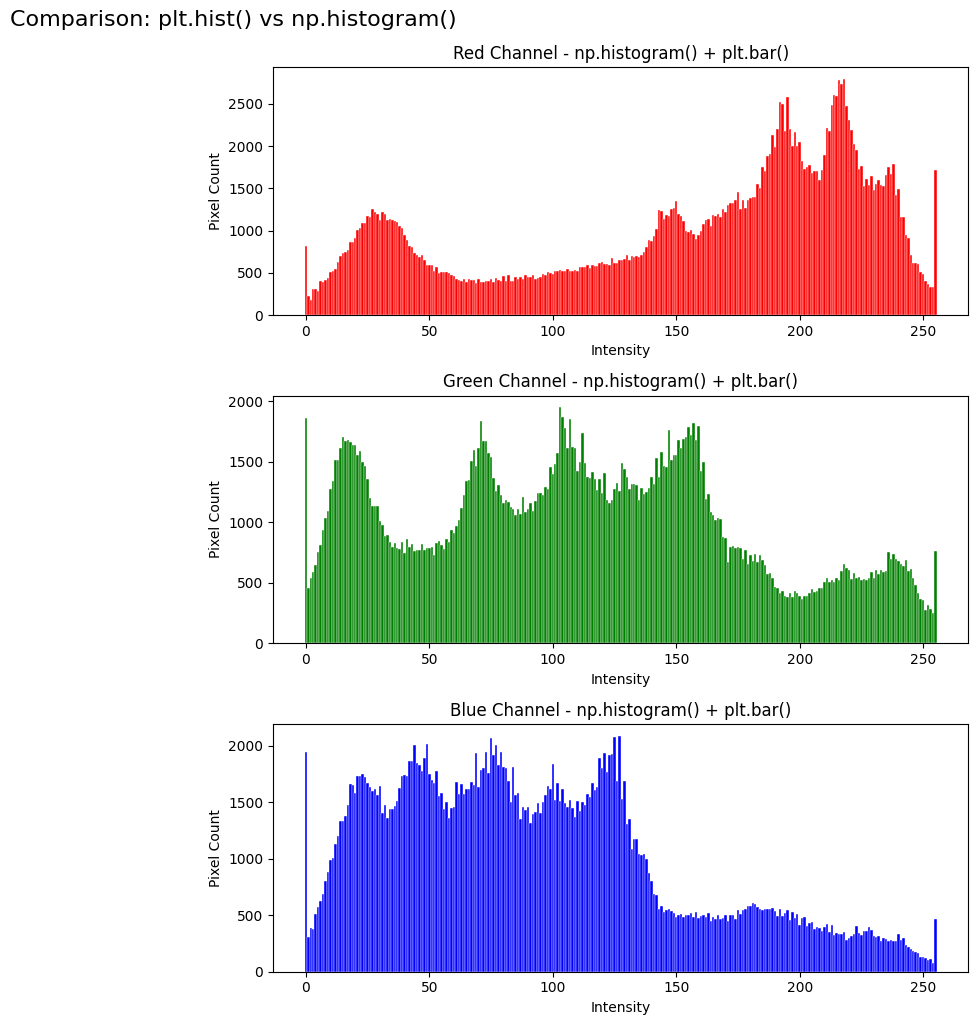

In [5]:
# Step 1: Load image and convert to RGB
image_path = "/content/drive/MyDrive/Images/lena.jpg"
image = cv.imread(image_path)
image_rgb = cv.cvtColor(image, cv.COLOR_BGR2RGB)  # Convert BGR to RGB for proper display

# Step 2: Define color channels
colors = ('red', 'green', 'blue')

# Step 3: Create a figure for plotting
plt.figure(figsize=(15, 10))

# Step 4: Loop through each RGB channel
for i, color in enumerate(colors):
    # Flatten the 2D channel data into 1D for histogram calculation
    channel_data = image_rgb[:, :, i].ravel()

    # Compute histogram using numpy
    hist, bins = np.histogram(channel_data, bins=256, range=(0, 256))

    # Plot histogram as a bar chart
    plt.subplot(3, 2, i*2 + 2)  # Positioning subplot (every second column)
    plt.bar(bins[:-1], hist, width=1.0, color=color, edgecolor='white', linewidth=0.3)
    plt.title(f'{color.capitalize()} Channel - np.histogram() + plt.bar()')
    plt.xlabel('Intensity')
    plt.ylabel('Pixel Count')

# Step 5: Adjust layout and add a super title
plt.tight_layout()
plt.suptitle("Comparison: plt.hist() vs np.histogram()", fontsize=16, y=1.02)
plt.show()

5.	Make an image histogram such as the output equalization histogram and also the image display before and after the following equalization histogram process based on the flowchart below : (Use image lena_lc .jpg)

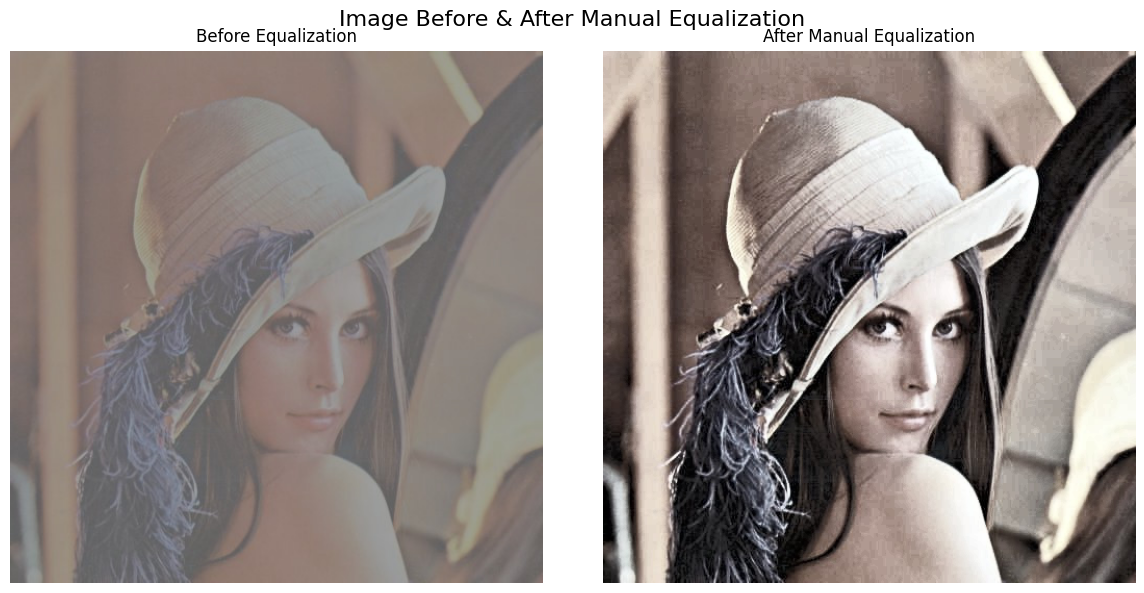

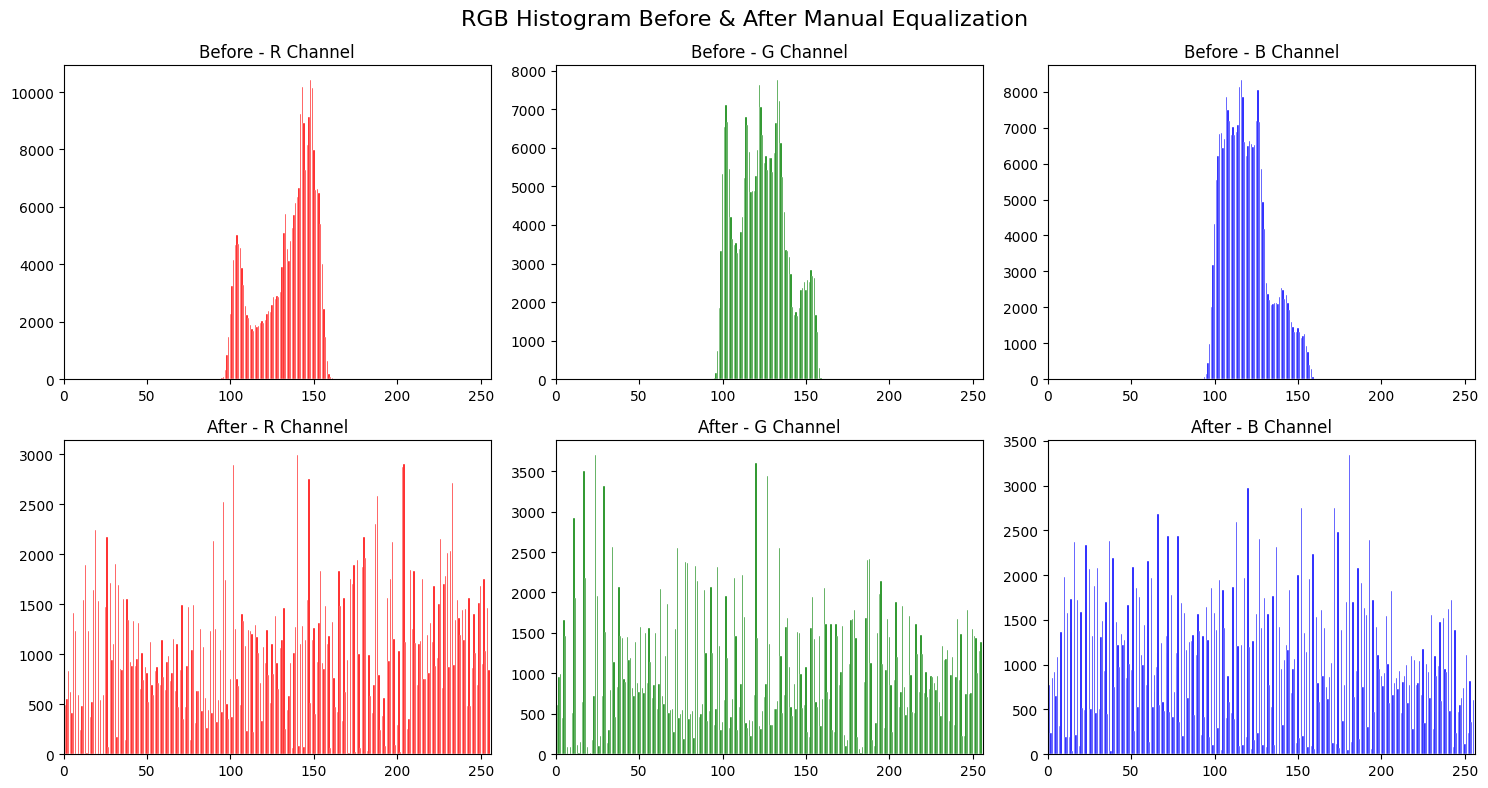

In [6]:
# Step 1: Load the low-contrast image
img_low = cv.imread("/content/drive/MyDrive/Images/lena_lc.jpg")
if img_low is None:
    raise FileNotFoundError("Check lena_lc.jpg path.")

# Step 2: Convert BGR (OpenCV default) to RGB for proper display with matplotlib
img_low_rgb = cv.cvtColor(img_low, cv.COLOR_BGR2RGB)

# Step 3: Convert the image to YCrCb color space and split channels
# Y channel represents luminance (brightness), Cr and Cb are chroma (color) channels
ycrcb = cv.cvtColor(img_low, cv.COLOR_BGR2YCrCb)
y, cr, cb = cv.split(ycrcb)

# Step 4: Perform manual histogram equalization on the Y channel
# 4a. Compute histogram of Y channel
hist, bins = np.histogram(y.flatten(), 256, [0,256])
# 4b. Compute cumulative distribution function (CDF)
cdf = hist.cumsum()
# 4c. Normalize CDF to range 0-255
cdf_normalized = cdf * 255 / cdf[-1]
# 4d. Map original pixel values through the normalized CDF to equalize brightness
y_eq = np.interp(y.flatten(), bins[:-1], cdf_normalized).reshape(y.shape).astype(np.uint8)

# Step 5: Merge equalized Y channel back with original Cr and Cb channels
# and convert back to RGB color space for display
ycrcb_eq = cv.merge([y_eq, cr, cb])
img_eq_rgb = cv.cvtColor(ycrcb_eq, cv.COLOR_YCrCb2RGB)

# Step 6: Define a function to plot RGB histograms
def plot_rgb_hist(axs, image, label):
    colors = ('r', 'g', 'b')
    for i, col in enumerate(colors):
        # Flatten the channel data for histogram calculation
        channel_data = image[:, :, i].ravel()
        # Compute histogram
        hist, bins = np.histogram(channel_data, bins=256, range=(0,256))
        # Plot histogram with thin white borders
        axs[i].bar(bins[:-1], hist, color=col, edgecolor='white', linewidth=0.3)
        axs[i].set_xlim([0,256])
        axs[i].set_title(f'{label} - {col.upper()} Channel')

# Step 7: Display original and equalized images side by side
plt.figure(figsize=(12,6))
plt.subplot(1,2,1)
plt.imshow(img_low_rgb)
plt.title("Before Equalization")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(img_eq_rgb)
plt.title("After Manual Equalization")
plt.axis("off")

plt.suptitle("Image Before & After Manual Equalization", fontsize=16)
plt.tight_layout()
plt.show()

# Step 8: Display RGB histograms of the images before and after equalization
fig, axs = plt.subplots(2, 3, figsize=(15,8))
plot_rgb_hist(axs[0], img_low_rgb, "Before")
plot_rgb_hist(axs[1], img_eq_rgb, "After")

plt.suptitle("RGB Histogram Before & After Manual Equalization", fontsize=16)
plt.tight_layout()
plt.show()

6.	After working on question no. 5, make the same image histogram but use the library owned by CV2, namely " equalizeHist ". Compare the results. Does the output appear the same?

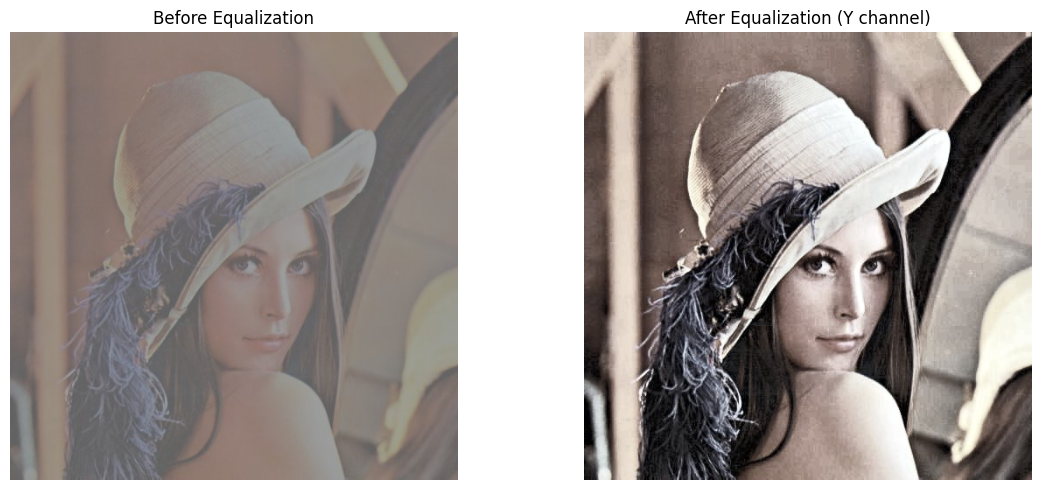

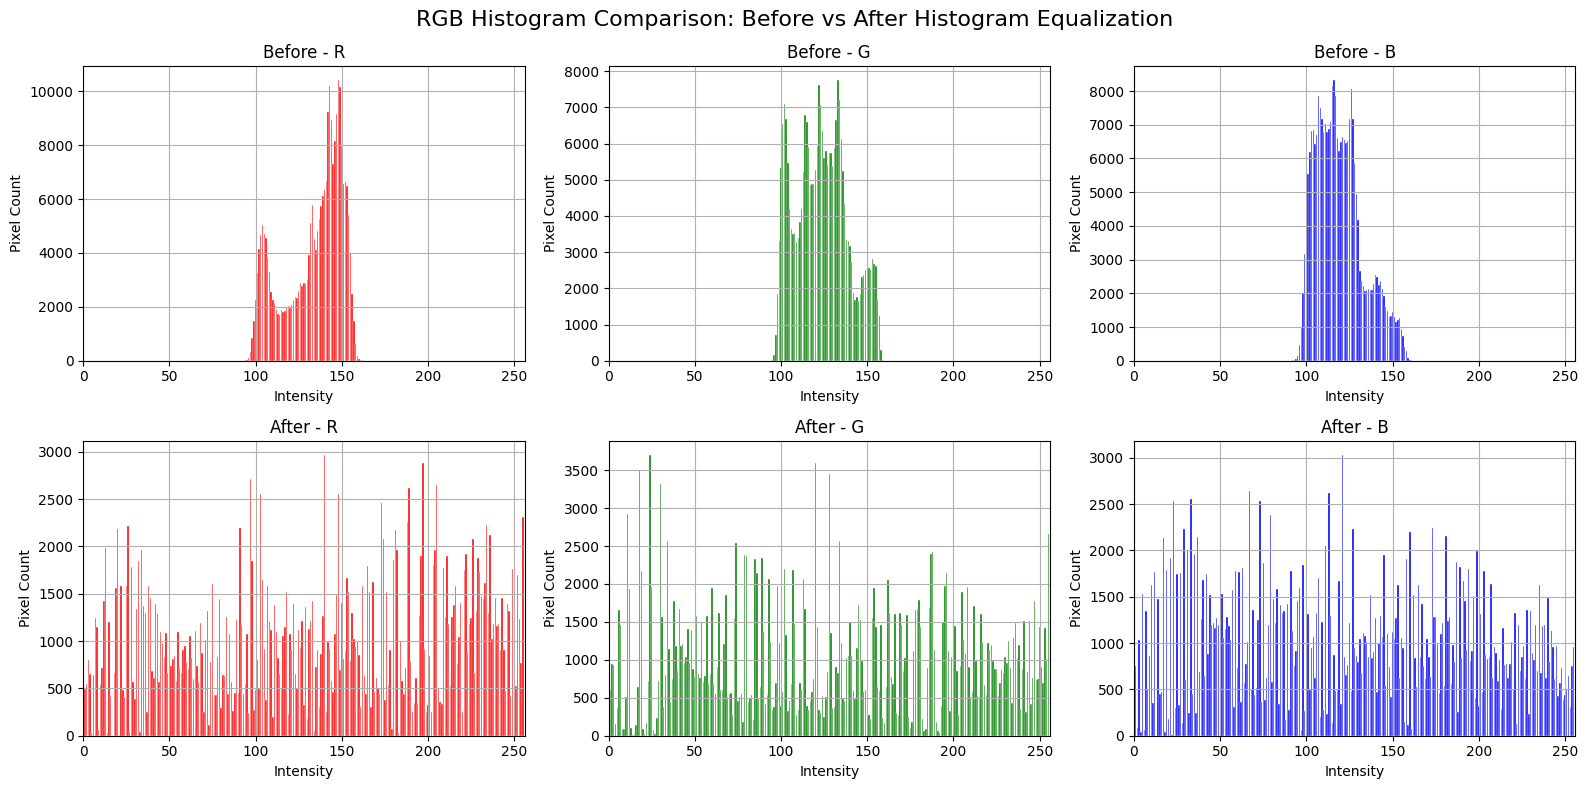

In [7]:
# Step 1: Load the low-contrast image
img_low = cv.imread("/content/drive/MyDrive/Images/lena_lc.jpg")

# Step 2: Convert BGR (OpenCV default) to RGB for proper display in matplotlib
img_low_rgb = cv.cvtColor(img_low, cv.COLOR_BGR2RGB)

# Step 3: Equalize only the Y (luminance) channel in YCrCb color space
ycrcb = cv.cvtColor(img_low, cv.COLOR_BGR2YCrCb)  # Convert to YCrCb
y, cr, cb = cv.split(ycrcb)                        # Split channels
y_eq = cv.equalizeHist(y)                          # Histogram equalization on Y
ycrcb_eq = cv.merge([y_eq, cr, cb])               # Merge channels back
img_eq_rgb = cv.cvtColor(ycrcb_eq, cv.COLOR_YCrCb2RGB)  # Convert back to RGB

# Step 4: Define function to plot RGB histograms
def plot_rgb_hist(axs, image, title):
    for i, color in enumerate(['r', 'g', 'b']):
        # Compute histogram for each channel
        hist = cv.calcHist([image], [i], None, [256], [0, 256])
        axs[i].bar(range(256), hist.ravel(), color=color, edgecolor='white', linewidth=0.3)
        axs[i].set_xlim([0, 256])
        axs[i].set_title(f"{title} - {color.upper()}")
        axs[i].set_xlabel("Intensity")
        axs[i].set_ylabel("Pixel Count")
        axs[i].grid(True)

# Step 5: Display original and equalized images side by side
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.imshow(img_low_rgb)
plt.title("Before Equalization")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(img_eq_rgb)
plt.title("After Equalization (Y channel)")
plt.axis("off")
plt.tight_layout()
plt.show()

# Step 6: Display RGB histograms for comparison
fig, axs = plt.subplots(2, 3, figsize=(16, 8))
plot_rgb_hist(axs[0], img_low_rgb, "Before")   # Histograms before equalization
plot_rgb_hist(axs[1], img_eq_rgb, "After")    # Histograms after equalization

plt.suptitle("RGB Histogram Comparison: Before vs After Histogram Equalization", fontsize=16)
plt.tight_layout()
plt.show()

7.	Do the mapping process of 16 million RGB colors into just 8 colors, namely black, green, yellow, blue, cyan, magenta, white as shown in the following output based on the flowchart below! (Use the image testlena .jpg)

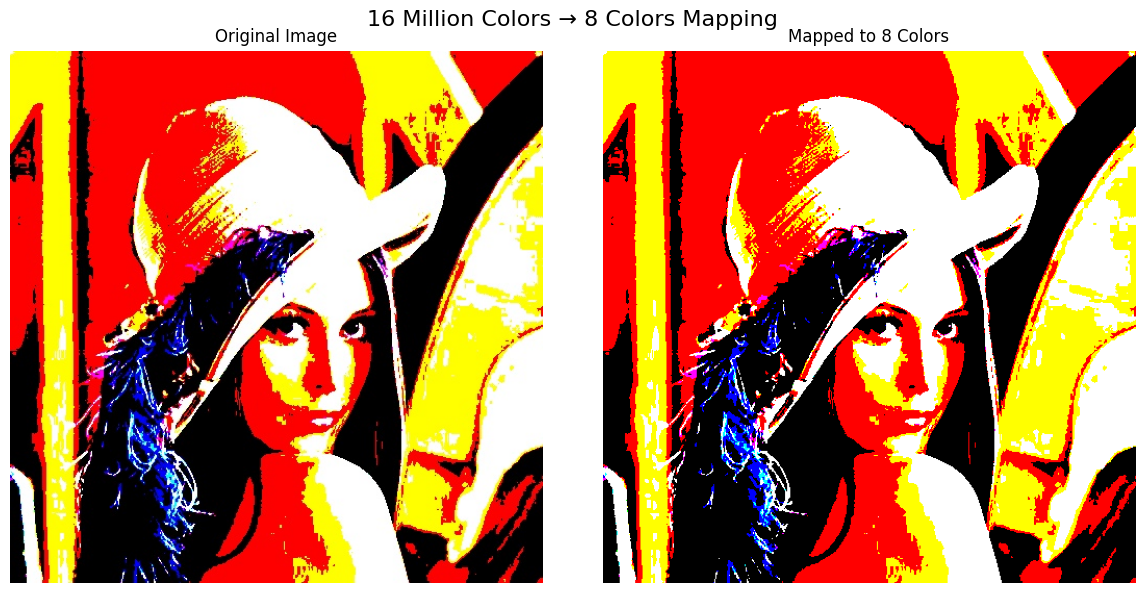

In [11]:
# Step 1: Load the image
img = cv.imread("/content/drive/MyDrive/Images/testlena.jpg")

# Convert BGR -> RGB for display
img_rgb = cv.cvtColor(img, cv.COLOR_BGR2RGB)  # <-- ganti cv2.COLOR_BGR2RGB menjadi cv.COLOR_BGR2RGB

# Step 2: Define function to map colors to 8-color palette
def map_to_8_colors(image):
    # Define 8 colors (RGB)
    colors = {
        'black':   np.array([0,0,0]),
        'green':   np.array([0,255,0]),
        'yellow':  np.array([255,255,0]),
        'blue':    np.array([0,0,255]),
        'cyan':    np.array([0,255,255]),
        'magenta': np.array([255,0,255]),
        'red':     np.array([255,0,0]),
        'white':   np.array([255,255,255])
    }

    # Flatten image for easy processing
    img_flat = image.reshape((-1,3))

    # Prepare output array
    mapped = np.zeros_like(img_flat)

    # Map each pixel
    for i, pixel in enumerate(img_flat):
        r,g,b = pixel
        # Threshold each channel to 0 or 255
        r_bin = 255 if r > 127 else 0
        g_bin = 255 if g > 127 else 0
        b_bin = 255 if b > 127 else 0
        mapped[i] = [r_bin, g_bin, b_bin]

    return mapped.reshape(image.shape)

# Step 3: Apply mapping
img_8colors = map_to_8_colors(img_rgb)

# Step 4: Display original and mapped image
plt.figure(figsize=(12,6))
plt.subplot(1,2,1)
plt.imshow(img_rgb)
plt.title("Original Image")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(img_8colors)
plt.title("Mapped to 8 Colors")
plt.axis("off")

plt.suptitle("16 Million Colors → 8 Colors Mapping", fontsize=16)
plt.tight_layout()
plt.show()

8.	Do the Floyd and Steinberg dithering process like the following output (initial image display, and after dithering display) based on the flowchart below! (Use wiki.jpg image)

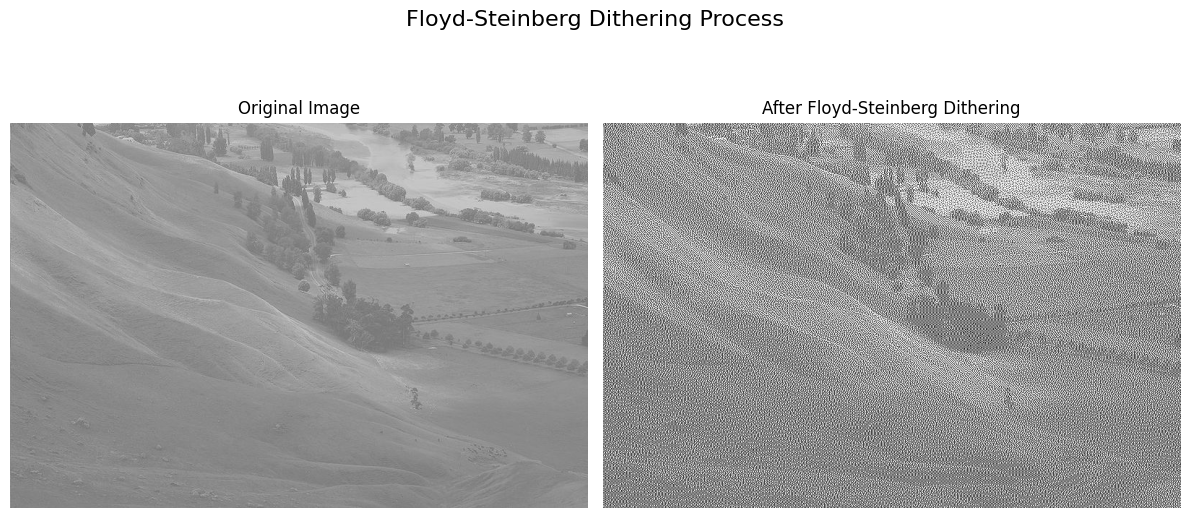

In [9]:
# Step 1: Load image
img = cv.imread("/content/drive/MyDrive/Images/wiki.jpg")
if img is None:
    raise FileNotFoundError("Check the path to wiki.jpg")

# Convert BGR -> RGB for display
img_rgb = cv.cvtColor(img, cv.COLOR_BGR2RGB)

# Step 2: Convert to grayscale
img_gray = cv.cvtColor(img, cv.COLOR_BGR2GRAY)

# Step 3: Floyd-Steinberg Dithering
def floyd_steinberg_dithering(image):
    # Convert to float for error diffusion
    img = image.astype(float)
    rows, cols = img.shape
    for y in range(rows):
        for x in range(cols):
            old_pixel = img[y, x]
            new_pixel = 0 if old_pixel < 128 else 255
            img[y, x] = new_pixel
            quant_error = old_pixel - new_pixel

            # Distribute the error
            if x + 1 < cols:
                img[y, x+1] += quant_error * 7/16
            if y + 1 < rows:
                if x > 0:
                    img[y+1, x-1] += quant_error * 3/16
                img[y+1, x] += quant_error * 5/16
                if x + 1 < cols:
                    img[y+1, x+1] += quant_error * 1/16
    return np.clip(img, 0, 255).astype(np.uint8)

# Apply dithering
img_dithered = floyd_steinberg_dithering(img_gray)

# Step 4: Display original and dithered images
plt.figure(figsize=(12,6))

plt.subplot(1,2,1)
plt.imshow(img_rgb)
plt.title("Original Image")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(img_dithered, cmap='gray')
plt.title("After Floyd-Steinberg Dithering")
plt.axis("off")

plt.suptitle("Floyd-Steinberg Dithering Process", fontsize=16)
plt.tight_layout()
plt.show()